<a href="https://colab.research.google.com/github/sivakrishnaps/AI-ML-session/blob/main/ndian_liver_data_perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

>**Problem:** Develop a `perceprton` model to classify the patients in the indian liver dataset to `having liver dicease` or `not having liver disease`

### About the dataset

This data set contains 416 liver patient records and 167 non liver patient records.The data set was collected from test samples in North East of Andhra Pradesh, India. 'is_patient' is a class label used to divide into groups(liver patient or not). This data set contains 441 male patient records and 142 female patient records.
Any patient whose age exceeded 89 is listed as being of age "90".

## Loading Necessary libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Define a function to clean the dataset

In [2]:
def clean_dataset(df):
    assert isinstance(df, pd.DataFrame), "df needs to be a pd.DataFrame"
    df.dropna(inplace=True)
    indices_to_keep = ~df.isin([np.nan, np.inf, -np.inf]).any(1)
    return df[indices_to_keep].astype(np.float64)

### Loading the dataset


In [3]:
# load from github repository
df3 = pd.read_csv('https://raw.githubusercontent.com/sijuswamy/PyWorks/main/indian_liver_patient.csv')
liverData=df3.iloc[:,3:11]

In [4]:
# showing first few records of df3
df3.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [5]:
clean_dataset(liverData)
print(liverData.head())

TypeError: DataFrame.any() takes 1 positional argument but 2 were given

In [6]:
# create the input matrix
X=liverData.iloc[:,:7]
print(X.head())

   Direct_Bilirubin  Alkaline_Phosphotase  Alamine_Aminotransferase  \
0               0.1                   187                        16   
1               5.5                   699                        64   
2               4.1                   490                        60   
3               0.4                   182                        14   
4               2.0                   195                        27   

   Aspartate_Aminotransferase  Total_Protiens  Albumin  \
0                          18             6.8      3.3   
1                         100             7.5      3.2   
2                          68             7.0      3.3   
3                          20             6.8      3.4   
4                          59             7.3      2.4   

   Albumin_and_Globulin_Ratio  
0                        0.90  
1                        0.74  
2                        0.89  
3                        1.00  
4                        0.40  


<Axes: >

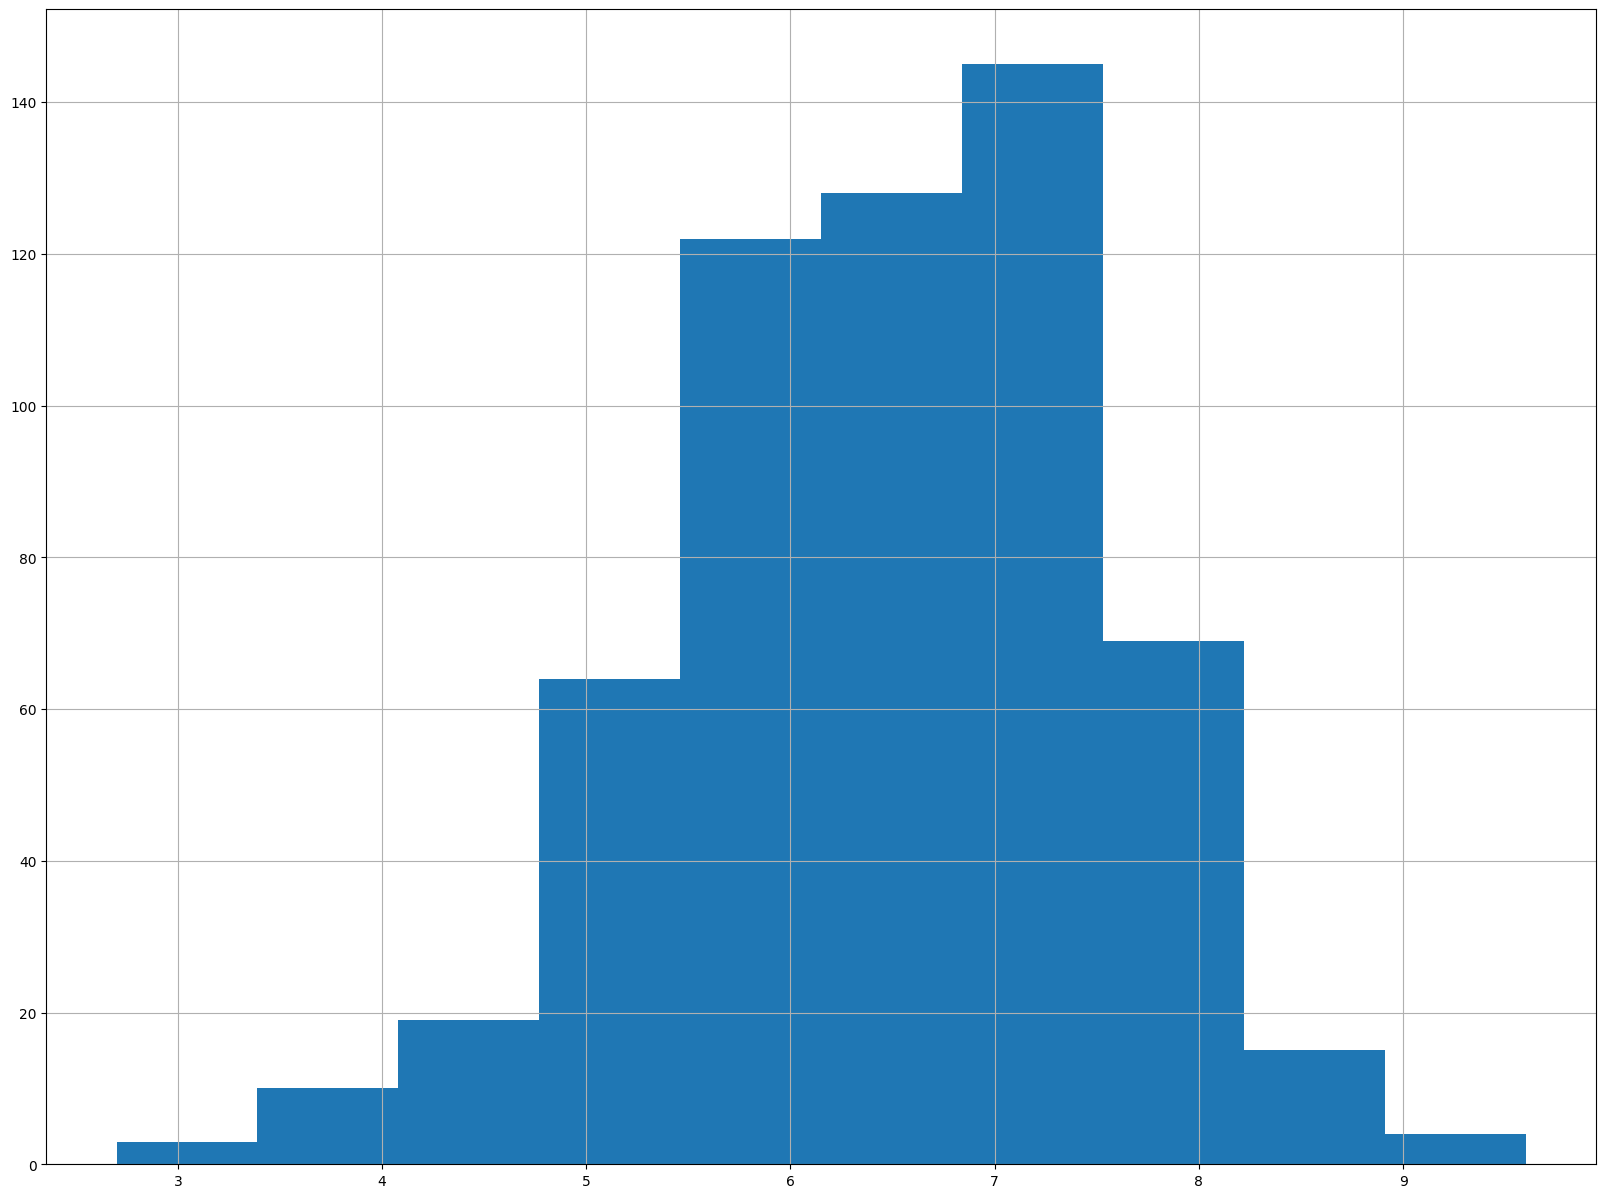

In [7]:
## just create a histograme of 4th feature
X.iloc[:,4].hist(bins=10,figsize=(20,15))

In [8]:
# create a five point summary of the input data
print("Summary statistics of Data:",X.describe())

Summary statistics of Data:        Direct_Bilirubin  Alkaline_Phosphotase  Alamine_Aminotransferase  \
count        579.000000            579.000000                579.000000   
mean           1.494128            291.366149                 81.126079   
std            2.816499            243.561863                183.182845   
min            0.100000             63.000000                 10.000000   
25%            0.200000            175.500000                 23.000000   
50%            0.300000            208.000000                 35.000000   
75%            1.300000            298.000000                 61.000000   
max           19.700000           2110.000000               2000.000000   

       Aspartate_Aminotransferase  Total_Protiens     Albumin  \
count                  579.000000      579.000000  579.000000   
mean                   110.414508        6.481693    3.138515   
std                    289.850034        1.084641    0.794435   
min                     10.000000   

array([[<Axes: title={'center': 'Direct_Bilirubin'}>,
        <Axes: title={'center': 'Alkaline_Phosphotase'}>,
        <Axes: title={'center': 'Alamine_Aminotransferase'}>],
       [<Axes: title={'center': 'Aspartate_Aminotransferase'}>,
        <Axes: title={'center': 'Total_Protiens'}>,
        <Axes: title={'center': 'Albumin'}>],
       [<Axes: title={'center': 'Albumin_and_Globulin_Ratio'}>, <Axes: >,
        <Axes: >]], dtype=object)

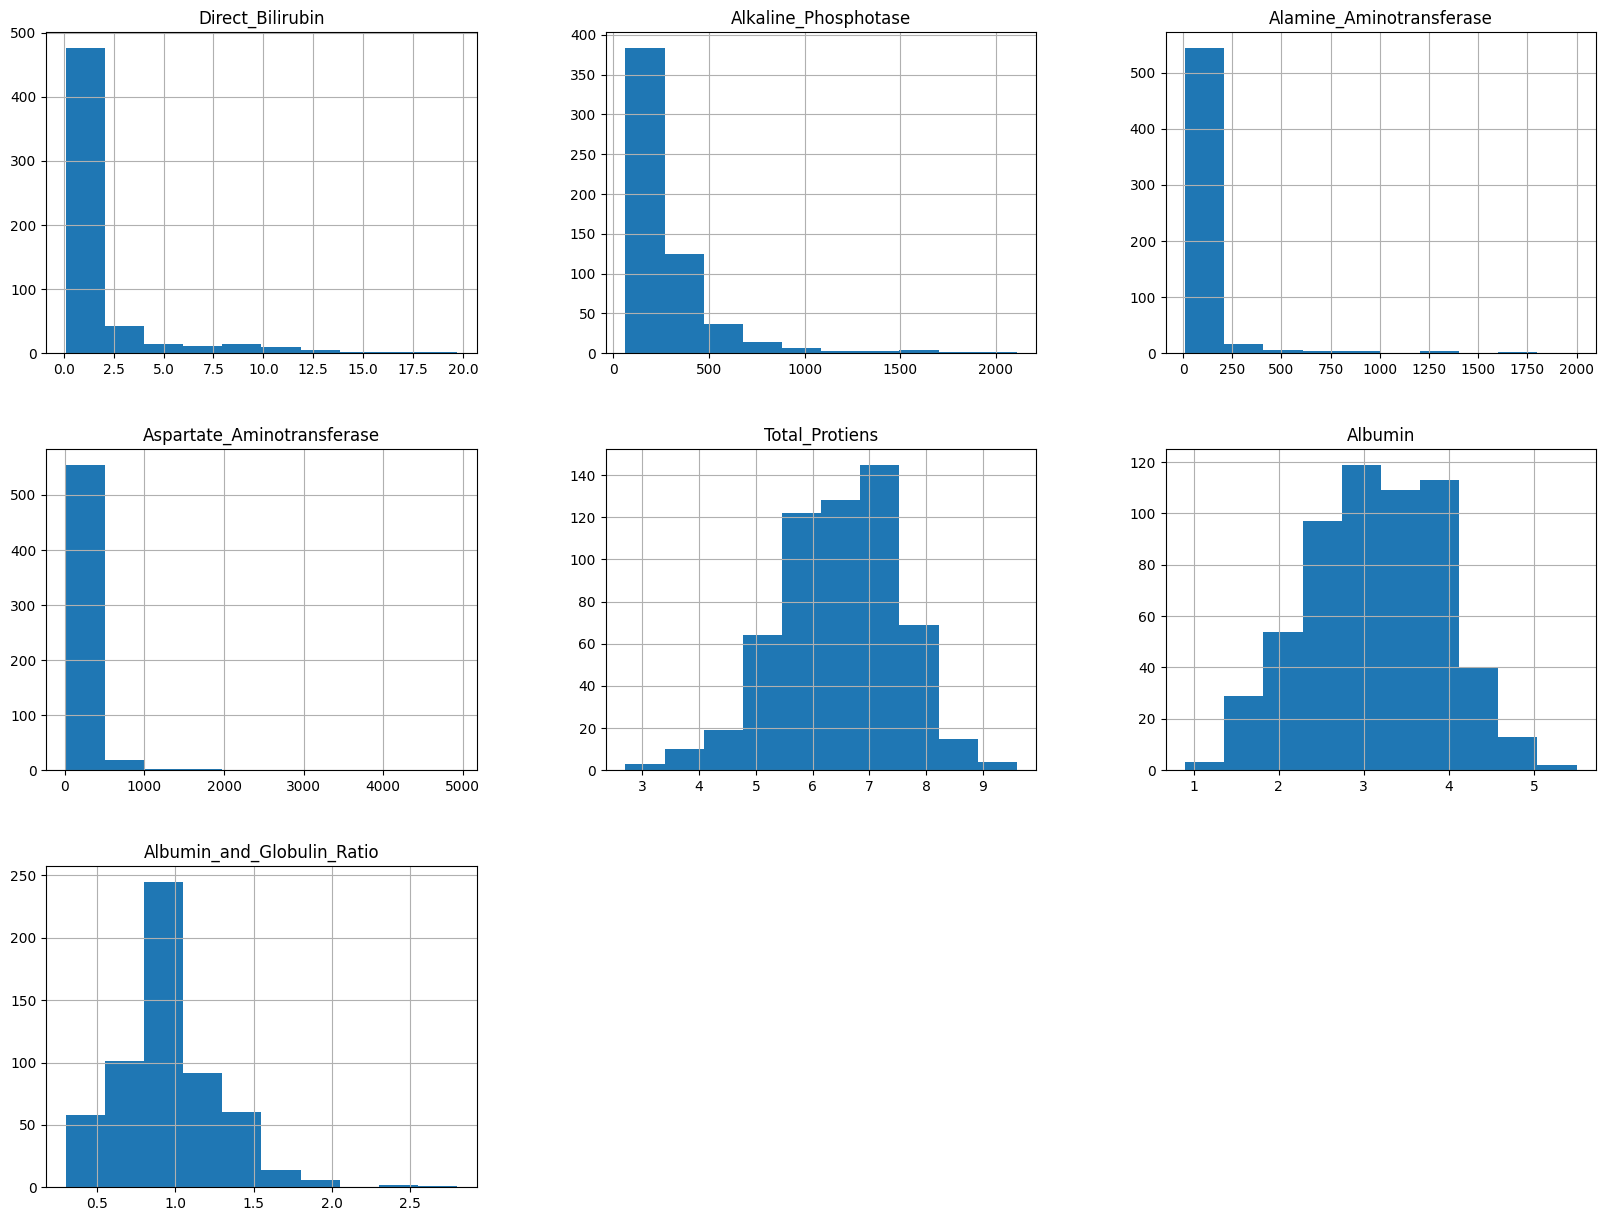

In [9]:
# create histogram of all numerical columns in X
X.hist(bins=10,figsize=(20,15))

### Creating the target variable as y

In [10]:
y=liverData.iloc[:,7]
print(y.head())

0    1
1    1
2    1
3    1
4    1
Name: Dataset, dtype: int64


In [11]:
print(type(y))


<class 'pandas.core.series.Series'>


In [12]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)
print(type(y))
print(y)

<class 'numpy.ndarray'>
[0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 1 0 0 0 1 1 0 0 1 1 1 0 1
 0 0 0 0 1 1 0 1 1 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 1 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1 1 1 1 1 1
 0 1 0 1 1 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0
 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 1 0 0 0 1 0 0 0 1 1 0 0 0 1 0 0 0 1 1 1 0 0 0 0 0 0 1 0 0 1 1 0 1 0 0 0 0
 1 0 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0
 0 0 1 1 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 1 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 1 0
 1 1 0 0 1 0 1 0 0 0 0 0 0 1 0 1 1 0 0 1 0 0 0 1 0 1 1 1 1 1 0 0 0 1 0 0 0
 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 1 1 1 1 1 1 1 0 0 0 1 0 1
 1 0 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0
 1 0 1 1 0 0 1 0 0 0 1 0 1 0 0 1 0 1 0 0 1 0 1 1 1 0 0 0 0 0 0 0 0 1 1 0 0
 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 1 1 1 1 0 0 0 1 1 1 1 1 0 0 0 0 1 0 0 1 0
 

### Spliting data into train and test

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=12)
print("Dimension of Training data:",X_train.shape)
print("Dimension of test data set:",X_test.shape)

Dimension of Training data: (463, 7)
Dimension of test data set: (116, 7)


## Creating a perceptron model from `sklern`

In [14]:
from sklearn.linear_model import Perceptron
perceptronClassifier=Perceptron()
perceptronClassifier.fit(X_train,y_train)

Perceptron()

### Test the accuracy on test data

In [15]:
score=perceptronClassifier.score(X_test,y_test)
print("Accuracy before standardization:",score)

Accuracy before standardization: 0.7155172413793104


### Creating Confidance interval for accuracy

In [16]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(perceptronClassifier, X_train, y_train, cv=5)
print("Accuracy: %0.2f (+/- %0.2f)" % (scores.mean(), scores.std() * 1.96))

Accuracy: 0.61 (+/- 0.21)


>**Conclusion:** From the confidance interval for accuracy of this perceptron model is (0.40,0.82). So better try another classification or try some scaling on the data.

In [17]:
# testing the model after standardization
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
sc.fit(X_train)
X_train_std=sc.transform(X_train)
X_test_std=sc.transform(X_test)
perceptronClassifier_std=Perceptron()
perceptronClassifier_std.fit(X_train_std,y_train)

Perceptron()

### Testing the performance of `perceptron` in the standardized data

In [18]:
score_std=perceptronClassifier_std.score(X_test_std,y_test)
print("Accuracy after standardization:",score_std)
y_predict=perceptronClassifier_std.predict(X_test_std[:10])

Accuracy after standardization: 0.7155172413793104


In [19]:
scores = cross_val_score(perceptronClassifier, X_train_std, y_train, cv=5)
print("Accuracy: %0.2f (+/- %0.2f)" % (scores.mean(), scores.std() * 1.96))

Accuracy: 0.65 (+/- 0.10)


In [20]:
print(scores.std())


0.052735482375952145
